In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path


In [3]:
# Define the path to the folder containing all CSV files
DATA_PATH = Path(r"C:\Users\Admin\Desktop\Cyclistic\Data\raw_data")

# Find all CSV files in the folder
csv_files = sorted(DATA_PATH.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files:\n")

for file in csv_files:
    print(file.name)

Found 12 CSV files:

202504-divvy-tripdata.csv
202505-divvy-tripdata.csv
202506-divvy-tripdata.csv
202507-divvy-tripdata.csv
202508-divvy-tripdata.csv
202509-divvy-tripdata.csv
202510-divvy-tripdata.csv
202511-divvy-tripdata.csv
202512-divvy-tripdata.csv
202601-divvy-tripdata.csv
202602-divvy-tripdata.csv
202603-divvy-tripdata.csv


In [4]:
# Read all CSV files into a list of DataFrames
dataframes = []

for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)

print(f"Successfully loaded {len(dataframes)} DataFrames.")

Successfully loaded 12 DataFrames.


In [5]:
# Combine all DataFrames into one
cyclistic_df = pd.concat(dataframes, ignore_index=True)

print("Combined DataFrame shape:", cyclistic_df.shape)

Combined DataFrame shape: (5620544, 13)


In [6]:
cyclistic_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5620544 entries, 0 to 5620543
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 557.5 MB


In [7]:
cyclistic_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,AF3863596DF9D94B,classic_bike,2025-04-27 14:29:34.619,2025-04-27 14:36:23.584,Troy St & Elston Ave,15631,Richmond St & Diversey Ave,15645,41.945244,-87.706650,41.931902,-87.701195,member
1,8B38081EBE918800,electric_bike,2025-04-23 17:48:51.863,2025-04-23 17:59:06.015,Wabash Ave & Adams St,KA1503000015,Green St & Madison St,TA1307000120,41.879472,-87.625689,41.881859,-87.649264,member
2,1C7F1DE826BBBC8D,electric_bike,2025-04-05 17:55:30.845,2025-04-05 18:05:40.032,Damen Ave & Cortland St,13133,California Ave & Fletcher St,15642,41.915983,-87.677335,41.938429,-87.698008,member
3,CAD23D69A79A6C3B,classic_bike,2025-04-03 08:22:04.493,2025-04-03 08:32:06.099,Clark St & Elm St,TA1307000039,Orleans St & Merchandise Mart Plaza,TA1305000022,41.902973,-87.631280,41.888243,-87.636390,member
4,BE241E601482E0AB,electric_bike,2025-04-15 06:09:55.293,2025-04-15 06:19:58.942,Western Ave & Walton St,KA1504000103,Damen Ave & Charleston St,13288,41.898418,-87.686596,41.920082,-87.677855,member


In [8]:
cyclistic_df.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1194952
start_station_id      1194952
end_station_name      1259214
end_station_id        1259214
start_lat                   0
start_lng                   0
end_lat                  5784
end_lng                  5784
member_casual               0
dtype: int64

In [9]:
cyclistic_df.duplicated().sum()

np.int64(0)

In [10]:
cyclistic_df["member_casual"].value_counts()

member_casual
member    3605045
casual    2015499
Name: count, dtype: int64

In [11]:
cyclistic_df["rideable_type"].value_counts()

rideable_type
electric_bike    3678925
classic_bike     1941619
Name: count, dtype: int64

In [12]:
# Convert date columns to datetime format
cyclistic_df["started_at"] = pd.to_datetime(cyclistic_df["started_at"])
cyclistic_df["ended_at"] = pd.to_datetime(cyclistic_df["ended_at"])

In [13]:
cyclistic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5620544 entries, 0 to 5620543
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             str           
 1   rideable_type       str           
 2   started_at          datetime64[us]
 3   ended_at            datetime64[us]
 4   start_station_name  str           
 5   start_station_id    str           
 6   end_station_name    str           
 7   end_station_id      str           
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       str           
dtypes: datetime64[us](2), float64(4), str(7)
memory usage: 557.5 MB


In [14]:
cyclistic_df["started_at"] = pd.to_datetime(cyclistic_df["started_at"])
cyclistic_df["ended_at"] = pd.to_datetime(cyclistic_df["ended_at"])

cyclistic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5620544 entries, 0 to 5620543
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             str           
 1   rideable_type       str           
 2   started_at          datetime64[us]
 3   ended_at            datetime64[us]
 4   start_station_name  str           
 5   start_station_id    str           
 6   end_station_name    str           
 7   end_station_id      str           
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       str           
dtypes: datetime64[us](2), float64(4), str(7)
memory usage: 557.5 MB


In [15]:
# Calculate ride duration
cyclistic_df["ride_length"] = (
    cyclistic_df["ended_at"] - cyclistic_df["started_at"]
)

In [16]:
cyclistic_df["ride_length"].head()

0   0 days 00:06:48.965000
1   0 days 00:10:14.152000
2   0 days 00:10:09.187000
3   0 days 00:10:01.606000
4   0 days 00:10:03.649000
Name: ride_length, dtype: timedelta64[us]

In [17]:
cyclistic_df["ride_length"].head()

0   0 days 00:06:48.965000
1   0 days 00:10:14.152000
2   0 days 00:10:09.187000
3   0 days 00:10:01.606000
4   0 days 00:10:03.649000
Name: ride_length, dtype: timedelta64[us]

In [18]:
# Day name (Monday, Tuesday, ...)
cyclistic_df["day_of_week"] = cyclistic_df["started_at"].dt.day_name()

# Month name (January, February, ...)
cyclistic_df["month"] = cyclistic_df["started_at"].dt.month_name()

# Hour of the day (0–23)
cyclistic_df["hour"] = cyclistic_df["started_at"].dt.hour

In [19]:
cyclistic_df[
    ["started_at", "ride_length", "day_of_week", "month", "hour"]
].head()

,started_at,ride_length,day_of_week,month,hour
0,2025-04-27 14:29:34.619,0 days 00:06:48.965000,Sunday,April,14
1,2025-04-23 17:48:51.863,0 days 00:10:14.152000,Wednesday,April,17
2,2025-04-05 17:55:30.845,0 days 00:10:09.187000,Saturday,April,17
3,2025-04-03 08:22:04.493,0 days 00:10:01.606000,Thursday,April,8
4,2025-04-15 06:09:55.293,0 days 00:10:03.649000,Tuesday,April,6


In [20]:
cyclistic_df["ride_length"].describe()

count                     5620544
mean       0 days 00:16:04.556038
std        0 days 00:55:45.664715
min      -1 days +23:05:12.312000
25%        0 days 00:05:23.118000
50%        0 days 00:09:25.103000
75%        0 days 00:16:34.085000
max        1 days 02:14:54.011000
Name: ride_length, dtype: object

In [21]:
invalid_rides = cyclistic_df[cyclistic_df["ride_length"] <= pd.Timedelta(0)]

print("Invalid rides:", len(invalid_rides))

Invalid rides: 29


In [22]:
# Remove rides with non-positive duration
cyclistic_df = cyclistic_df[
    cyclistic_df["ride_length"] > pd.Timedelta(0)
].copy()

print("New shape:", cyclistic_df.shape)

New shape: (5620515, 17)


### Data Cleaning

- Combined 12 monthly datasets into a single DataFrame.
- Converted `started_at` and `ended_at` from string to datetime.
- Created new features:
  - `ride_length`
  - `day_of_week`
  - `month`
  - `hour`
- Checked for duplicate records (none found).
- Identified 29 rides with non-positive durations.
- Removed those invalid rides because they are not meaningful for trip analysis.

In [23]:
cyclistic_df.groupby("member_casual")["ride_length"].mean()

member_casual
casual   0 days 00:22:35.601497
member   0 days 00:12:25.959093
Name: ride_length, dtype: timedelta64[us]

Casual riders have an average ride duration of approximately 22.6 minutes, compared with 12.4 minutes for annual members. This indicates that casual riders are more likely to use the bike-share service for leisure, whereas members appear to use it for shorter, routine journeys such as commuting.

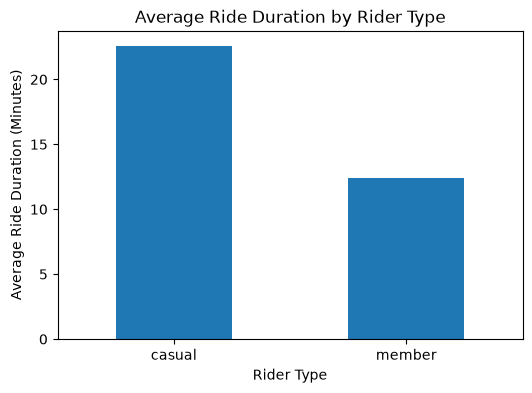

In [24]:
avg_ride = (
    cyclistic_df
    .groupby("member_casual")["ride_length"]
    .mean()
    .dt.total_seconds() / 60
)

avg_ride.plot(kind="bar", figsize=(6,4))

plt.title("Average Ride Duration by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Average Ride Duration (Minutes)")
plt.xticks(rotation=0)

plt.show()

In [25]:
rides_by_day = (
    cyclistic_df
    .groupby(["day_of_week", "member_casual"])
    .size()
    .unstack()
)

# Reorder the days
days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

rides_by_day = rides_by_day.reindex(days)

rides_by_day

member_casual,casual,member
day_of_week,,
Monday,234307,511371
Tuesday,227855,580928
Wednesday,224333,562336
Thursday,259660,581378
Friday,315030,529778
Saturday,416045,451808
Sunday,338260,387426


In [26]:
rides_by_hour = (
    cyclistic_df
    .groupby(["hour", "member_casual"])
    .size()
    .unstack()
)

rides_by_hour

member_casual,casual,member
hour,,
0,39545,32824
1,25296,20224
2,16896,12203
3,9301,7990
4,7363,9043
5,11727,35173
6,27013,102587
7,50212,203637
8,71285,261786


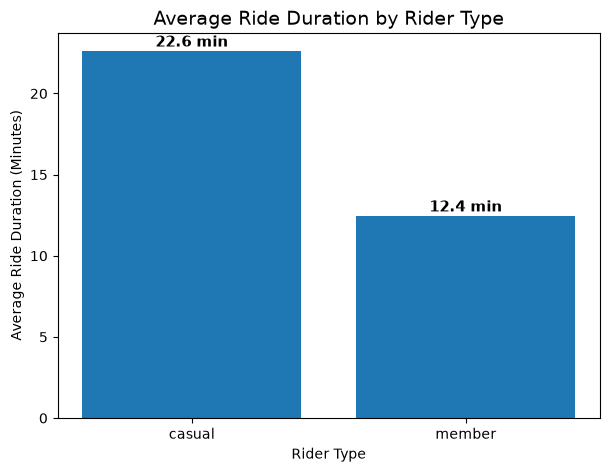

In [27]:
avg_ride = (
    cyclistic_df
    .groupby("member_casual")["ride_length"]
    .mean()
    .dt.total_seconds() / 60
)

plt.figure(figsize=(7,5))

plt.bar(avg_ride.index, avg_ride.values)

plt.title("Average Ride Duration by Rider Type", fontsize=14)
plt.xlabel("Rider Type")
plt.ylabel("Average Ride Duration (Minutes)")

for i, value in enumerate(avg_ride.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f} min",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.show()

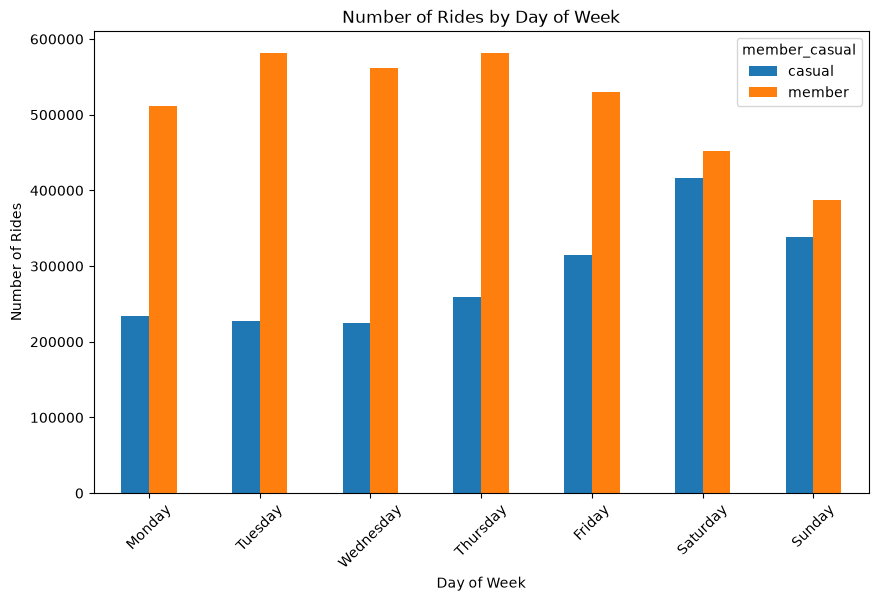

In [28]:
rides_by_day.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Number of Rides by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.show()

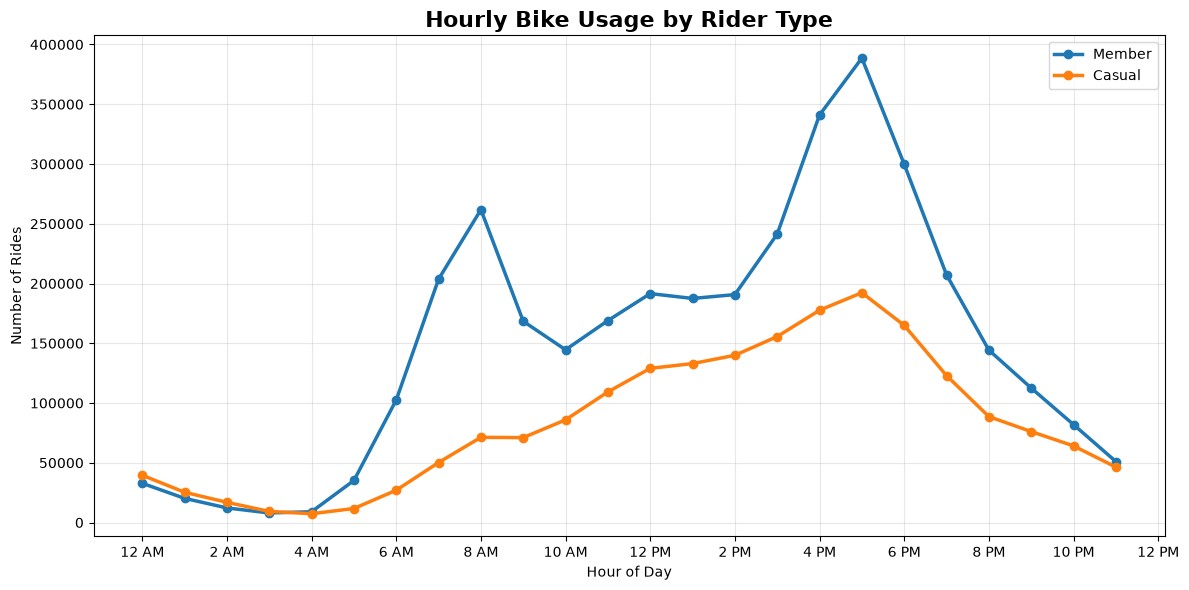

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    rides_by_hour.index,
    rides_by_hour["member"],
    label="Member",
    linewidth=2.5,
    marker="o"
)

plt.plot(
    rides_by_hour.index,
    rides_by_hour["casual"],
    label="Casual",
    linewidth=2.5,
    marker="o"
)

plt.title("Hourly Bike Usage by Rider Type", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")

# <-- Put the x-axis labels here
plt.xticks(
    range(0, 26, 2),
    [
        "12 AM",
        "2 AM",
        "4 AM",
        "6 AM",
        "8 AM",
        "10 AM",
        "12 PM",
        "2 PM",
        "4 PM",
        "6 PM",
        "8 PM",
        "10 PM",
        "12 PM"
    ]
)

# Optional but highly recommended
plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [30]:
rides_by_month = (
    cyclistic_df
    .groupby(["month", "member_casual"])
    .size()
    .unstack()
)

In [31]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

rides_by_month = rides_by_month.reindex(month_order)

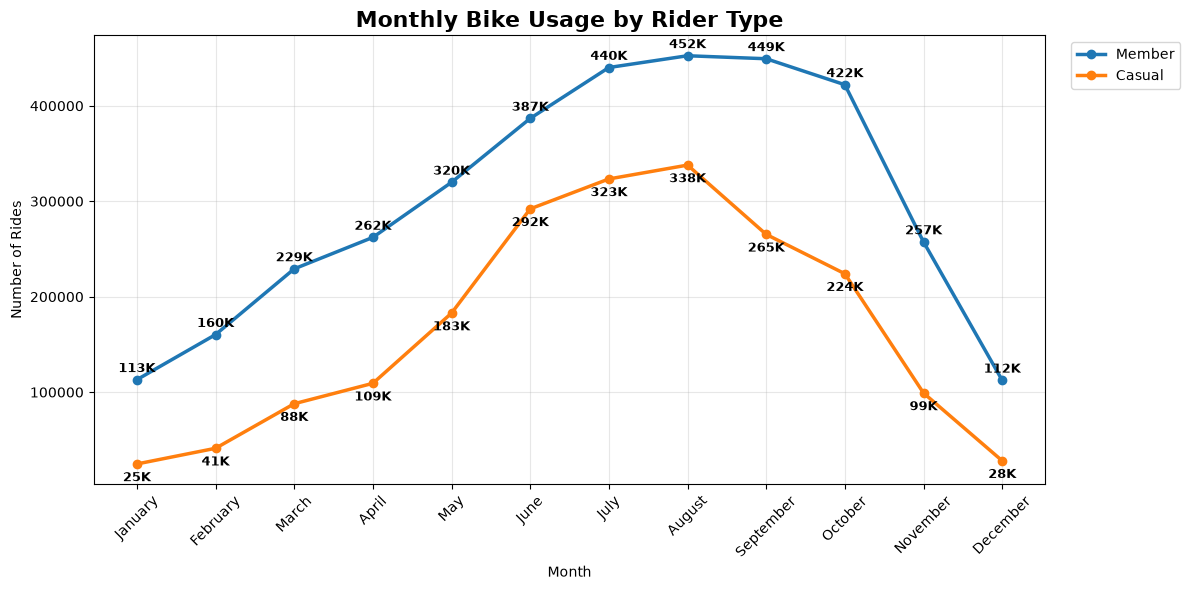

In [32]:
plt.figure(figsize=(12,6))

plt.plot(
    rides_by_month.index,
    rides_by_month["member"],
    label="Member",
    linewidth=2.5,
    marker="o"
)

plt.plot(
    rides_by_month.index,
    rides_by_month["casual"],
    label="Casual",
    linewidth=2.5,
    marker="o"
)

# -------- Member Labels --------
for x, y in zip(rides_by_month.index, rides_by_month["member"]):
    plt.text(
        x,
        y + 8000,
        f"{y/1000:.0f}K",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# -------- Casual Labels --------
for x, y in zip(rides_by_month.index, rides_by_month["casual"]):
    plt.text(
        x,
        y - 18000,
        f"{y/1000:.0f}K",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Monthly Bike Usage by Rider Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()

plt.show()

In [33]:
cyclistic_df.groupby("member_casual")["ride_length"].mean()

member_casual
casual   0 days 00:22:35.601497
member   0 days 00:12:25.959093
Name: ride_length, dtype: timedelta64[us]

In [34]:
cyclistic_df.groupby("day_of_week").size()

day_of_week
Friday       844808
Monday       745678
Saturday     867853
Sunday       725686
Thursday     841038
Tuesday      808783
Wednesday    786669
dtype: int64

In [35]:
cyclistic_df.groupby("rideable_type")["ride_length"].mean()

rideable_type
classic_bike    0 days 00:23:34.102248
electric_bike   0 days 00:12:07.327679
Name: ride_length, dtype: timedelta64[us]

In [36]:
cyclistic_df.to_csv(
    "cyclistic_cleaned.csv",
    index=False
)

In [37]:
cyclistic_df["ride_length_minutes"] = (
    cyclistic_df["ride_length"].dt.total_seconds() / 60
).round(2)

In [38]:
cyclistic_df[["ride_length", "ride_length_minutes"]].head()

,ride_length,ride_length_minutes
0,0 days 00:06:48.965000,6.82
1,0 days 00:10:14.152000,10.24
2,0 days 00:10:09.187000,10.15
3,0 days 00:10:01.606000,10.03
4,0 days 00:10:03.649000,10.06
